[array([ 0,  0,  1,  0,  3,  6,  7,  8,  8, 17, 14, 12, 14, 23, 17, 22, 17,
        8,  7,  2,  5,  4,  2,  1,  0,  1,  1,  0,  0,  0])]
[ 90.          92.33333333  94.66666667  97.          99.33333333
 101.66666667 104.         106.33333333 108.66666667 111.
 113.33333333 115.66666667 118.         120.33333333 122.66666667
 125.         127.33333333 129.66666667 132.         134.33333333
 136.66666667 139.         141.33333333 143.66666667 146.
 148.33333333 150.66666667 153.         155.33333333 157.66666667
 160.        ]
[array([ 0,  0,  1,  0,  3,  6,  7,  8,  8, 17, 14, 12, 14, 23, 17, 22, 17,
        8,  7,  2,  5,  4,  2,  1,  0,  1,  1,  0,  0,  0]), array([ 0,  0,  0,  0,  0,  0,  0,  3,  3,  4, 10,  4,  5, 13, 15, 12, 10,
       12, 12,  9, 11, 10,  5,  6,  2,  1,  0,  2,  0,  1])]
[ 90.          92.33333333  94.66666667  97.          99.33333333
 101.66666667 104.         106.33333333 108.66666667 111.
 113.33333333 115.66666667 118.         120.33333333 122.66666667
 125.

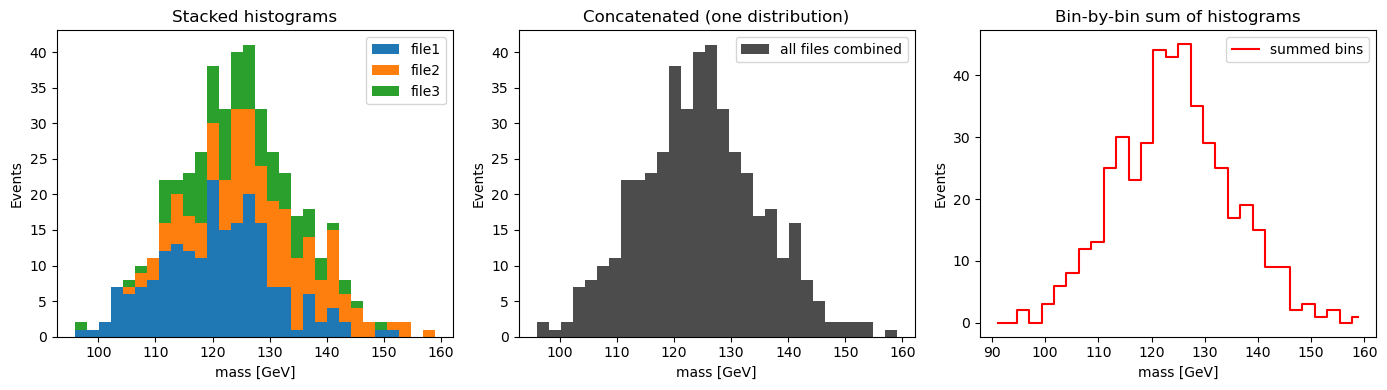

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fake "diphoton_mass" arrays from 3 files
file1 = np.random.normal(120, 10, 200)   # mean 120, 200 events
file2 = np.random.normal(130, 10, 150)   # mean 130, 150 events
file3 = np.random.normal(125, 10, 100)   # mean 125, 100 events

arrays = [file1, file2, file3]

# ----------------------------
# 1. STACKED: keep arrays separate
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.hist(arrays, bins=30, stacked=True, label=["file1","file2","file3"])
plt.title("Stacked histograms")
plt.xlabel("mass [GeV]")
plt.ylabel("Events")
plt.legend()

# ----------------------------
# 2. CONCATENATED: merge into one array
all_events = np.concatenate(arrays)
plt.subplot(1,3,2)
plt.hist(all_events, bins=30, color="black", alpha=0.7, label="all files combined")
plt.title("Concatenated (one distribution)")
plt.xlabel("mass [GeV]")
plt.ylabel("Events")
plt.legend()

# ----------------------------
# 3. BIN-BY-BIN SUM: add hist counts directly
counts = []
bin_edges = None
for arr in arrays:
    h, bins = np.histogram(arr, bins=30, range=(90,160))
    counts.append(h)
    print(counts)
    bin_edges = bins
    print(bin_edges)

# sum over files
sum_counts = np.sum(counts, axis=0)
bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

plt.subplot(1,3,3)
plt.step(bin_centers, sum_counts, where="mid", label="summed bins", color="red")
plt.title("Bin-by-bin sum of histograms")
plt.xlabel("mass [GeV]")
plt.ylabel("Events")
plt.legend()

plt.tight_layout()
plt.show()